In [1]:
# Libraries
import pandas as pd
from sqlalchemy import create_engine
import sqlite3


In [2]:
engine = create_engine("sqlite:///../db/cc_intelligence.db")

# Dataset 1 — fraud transactions

In [3]:
df_fraud = pd.read_csv("../data/creditcard.csv")
df_fraud.to_sql("transactions", engine, if_exists="replace", index=False)
print(f"Loaded {len(df_fraud)} rows into 'transactions'")

Loaded 284807 rows into 'transactions'


# Dataset 2 — credit default users

In [4]:
df_credit = pd.read_csv("../data/UCI_Credit_Card.csv")
df_credit.columns = df_credit.columns.str.lower().str.strip()
df_credit.to_sql("credit_users", engine, if_exists="replace", index=False)
print(f"Loaded {len(df_credit):,} rows into 'credit_users'")

Loaded 30,000 rows into 'credit_users'


In [5]:
con = sqlite3.connect("../db/cc_intelligence.db")
print(pd.read_sql("SELECT * FROM transactions LIMIT 3", con))
print(pd.read_sql("SELECT * FROM credit_users LIMIT 3", con))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  
2 -0.139097 -0.055353 -0.059752  378.66      0  

[3 rows x 31 columns]
   id  limit_bal  sex  education  marriage  age  pay_0  pay_2  pay_3  pay_4  \
0   1    20000.0    2          2         1   24      2  

In [6]:
%reload_ext sql

In [7]:
%load_ext sql
%sql sqlite:///../db/cc_intelligence.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [10]:
%config SqlMagic.style = 'PLAIN_COLUMNS'

In [12]:
%%sql
PRAGMA table_info(transactions);

 * sqlite:///../db/cc_intelligence.db
Done.


cid,name,type,notnull,dflt_value,pk
0,Time,FLOAT,0,None,0
1,V1,FLOAT,0,None,0
2,V2,FLOAT,0,None,0
3,V3,FLOAT,0,None,0
4,V4,FLOAT,0,None,0
5,V5,FLOAT,0,None,0
6,V6,FLOAT,0,None,0
7,V7,FLOAT,0,None,0
8,V8,FLOAT,0,None,0
9,V9,FLOAT,0,None,0


In [13]:
%%sql
SELECT * FROM transactions
LIMIT 5;

 * sqlite:///../db/cc_intelligence.db
Done.


Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0.0,-1.3598071336738,-0.0727811733098497,2.53634673796914,1.37815522427443,-0.338320769942518,0.462387777762292,0.239598554061257,0.0986979012610507,0.363786969611213,0.0907941719789316,-0.551599533260813,-0.617800855762348,-0.991389847235408,-0.311169353699879,1.46817697209427,-0.470400525259478,0.207971241929242,0.0257905801985591,0.403992960255733,0.251412098239705,-0.018306777944153,0.277837575558899,-0.110473910188767,0.0669280749146731,0.128539358273528,-0.189114843888824,0.133558376740387,-0.0210530534538215,149.62,0
0.0,1.19185711131486,0.26615071205963,0.16648011335321,0.448154078460911,0.0600176492822243,-0.0823608088155687,-0.0788029833323113,0.0851016549148104,-0.255425128109186,-0.166974414004614,1.61272666105479,1.06523531137287,0.48909501589608,-0.143772296441519,0.635558093258208,0.463917041022171,-0.114804663102346,-0.183361270123994,-0.145783041325259,-0.0690831352230203,-0.225775248033138,-0.638671952771851,0.101288021253234,-0.339846475529127,0.167170404418143,0.125894532368176,-0.0089830991432281,0.0147241691924927,2.69,0
1.0,-1.35835406159823,-1.34016307473609,1.77320934263119,0.379779593034328,-0.503198133318193,1.80049938079263,0.791460956450422,0.247675786588991,-1.51465432260583,0.207642865216696,0.624501459424895,0.066083685268831,0.717292731410831,-0.165945922763554,2.34586494901581,-2.89008319444231,1.10996937869599,-0.121359313195888,-2.26185709530414,0.524979725224404,0.247998153469754,0.771679401917229,0.909412262347719,-0.689280956490685,-0.327641833735251,-0.139096571514147,-0.0553527940384261,-0.0597518405929204,378.66,0
1.0,-0.966271711572087,-0.185226008082898,1.79299333957872,-0.863291275036453,-0.0103088796030823,1.24720316752486,0.23760893977178,0.377435874652262,-1.38702406270197,-0.0549519224713749,-0.226487263835401,0.178228225877303,0.507756869957169,-0.28792374549456,-0.631418117709045,-1.0596472454325,-0.684092786345479,1.96577500349538,-1.2326219700892,-0.208037781160366,-0.108300452035545,0.0052735967825345,-0.190320518742841,-1.17557533186321,0.647376034602038,-0.221928844458407,0.0627228487293033,0.0614576285006353,123.5,0
2.0,-1.15823309349523,0.877736754848451,1.548717846511,0.403033933955121,-0.407193377311653,0.0959214624684256,0.592940745385545,-0.270532677192282,0.817739308235294,0.753074431976354,-0.822842877946363,0.53819555014995,1.3458515932154,-1.11966983471731,0.175121130008994,-0.451449182813529,-0.237033239362776,-0.0381947870352842,0.803486924960175,0.408542360392758,-0.0094306971323291,0.79827849458971,-0.137458079619063,0.141266983824769,-0.206009587619756,0.502292224181569,0.219422229513348,0.215153147499206,69.99,0


### Basic statistics of amount

In [ ]:

%%sql
SELECT 
    COUNT(*) AS total_rows,
    MIN(Amount) AS min_amt,
    MAX(Amount) AS max_amt,
    AVG(Amount) AS avg_amt
FROM transactions;

 * sqlite:///../db/cc_intelligence.db
Done.


total_rows,min_amt,max_amt,avg_amt
284807,0.0,25691.16,88.34961925093134


### Class distribution — how imbalanced is fraud?

In [11]:
%%sql
SELECT 
    Class,
    COUNT(*) AS txn_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 4) AS pct
FROM transactions
GROUP BY Class;

 * sqlite:///../db/cc_intelligence.db
Done.


Class,txn_count,pct
0,284315,99.8273
1,492,0.1727


**Severe class imbalance**: Only 0.17% of transactions are fraud (492 out of 284,807).
   This means a model that predicts "always legit" would be 99.83% accurate — but useless.
   

<Axes: xlabel='Class'>

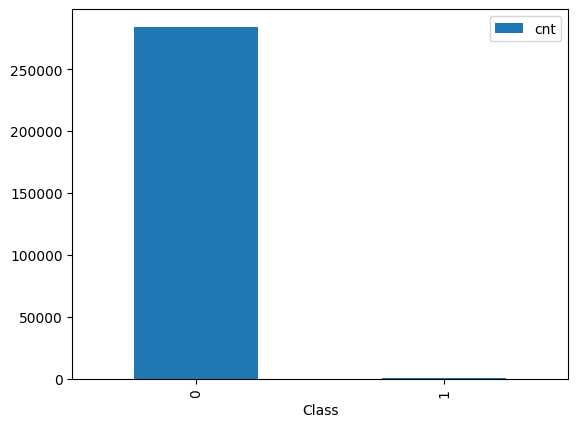

In [35]:
# class distribution
df = pd.read_sql("SELECT Class, COUNT(*) as cnt FROM transactions GROUP BY Class", con)
df.plot(kind='bar', x='Class', y='cnt')

### Spend bucket distribution (legit only)

In [27]:
%%sql
SELECT
    CASE
        WHEN Amount < 10    THEN '< $10'
        WHEN Amount < 50    THEN '$10–$50'
        WHEN Amount < 100   THEN '$50–$100'
        WHEN Amount < 500   THEN '$100–$500'
        ELSE                     '> $500'
    END AS spend_bucket,
    COUNT(*) AS txn_count,
    ROUND(AVG(Amount), 2) AS avg_amount
FROM transactions
WHERE Class = 0
GROUP BY spend_bucket
ORDER BY MIN(Amount);

 * sqlite:///../db/cc_intelligence.db
Done.


spend_bucket,txn_count,avg_amount
< $10,97065,3.71
$10–$50,92334,25.1
$50–$100,37661,71.82
$100–$500,47798,208.39
> $500,9457,1031.98


### Analyzing transaction amount by class

In [32]:

%%sql
SELECT 
    Class,
    COUNT(Amount) AS count,
    
    MAX(Amount) AS max_amt,
    AVG(Amount) AS avg_amt
FROM transactions
GROUP BY Class;

 * sqlite:///../db/cc_intelligence.db
Done.


Class,count,max_amt,avg_amt
0,284315,25691.16,88.29102242231328
1,492,2125.87,122.21132113821139


**Fraud transactions average higher amounts**: Avg fraud = $122 vs avg legit = $88.
   But max fraud ($2,125) is far lower than max legit ($25,691) — very large amounts
   are likely corporate/B2B transactions, not fraud targets.

In [34]:
%%sql
SELECT 
    Class,
    COUNT(*) 
FROM transactions
WHERE Amount = 0
GROUP BY Class;

 * sqlite:///../db/cc_intelligence.db
Done.


Class,COUNT(*)
0,1798
1,27


 **1,798 zero-amount transactions exist**: These are likely authorization checks.
- A $0 transaction is nearly 9 times more likely to be fraud than a random transaction in your dataset.

### High-value fraud — top 10 fraud amounts

In [43]:
%%sql
SELECT Amount, Time
FROM transactions
WHERE Class = 1
ORDER BY Amount DESC
LIMIT 10;

 * sqlite:///../db/cc_intelligence.db
Done.


Amount,Time
2125.87,122608.0
1809.68,9064.0
1504.93,154278.0
1402.16,62467.0
1389.56,59011.0
1354.25,65385.0
1335.0,133184.0
1218.89,18088.0
1096.99,154309.0
996.27,147501.0


### Fraud rate by hour of day

In [29]:
%%sql
SELECT
    (CAST(Time AS INT) / 3600) % 24 AS hour_of_day,
    COUNT(*) AS total_txns,
    SUM(Class) AS fraud_count,
    ROUND(SUM(Class) * 100.0 / COUNT(*), 3) AS fraud_rate_pct
FROM transactions
GROUP BY hour_of_day
ORDER BY hour_of_day;

 * sqlite:///../db/cc_intelligence.db
Done.


hour_of_day,total_txns,fraud_count,fraud_rate_pct
0,7695,6,0.078
1,4220,10,0.237
2,3328,57,1.713
3,3492,17,0.487
4,2209,23,1.041
5,2990,11,0.368
6,4101,9,0.219
7,7243,23,0.318
8,10276,9,0.088
9,15838,16,0.101


<Axes: xlabel='hour_of_day'>

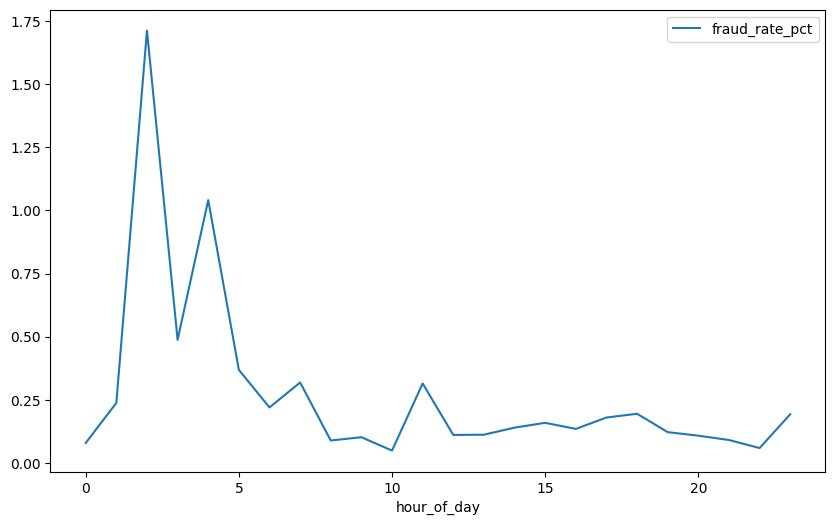

In [40]:
df_hour = pd.read_sql("""
SELECT
    (CAST(Time AS INT) / 3600) % 24 AS hour_of_day,
    COUNT(*) AS total_txns,
    SUM(Class) AS fraud_count,
    ROUND(SUM(Class) * 100.0 / COUNT(*), 3) AS fraud_rate_pct
FROM transactions
GROUP BY hour_of_day
ORDER BY hour_of_day;
""", con)

df_hour.plot(x='hour_of_day', y='fraud_rate_pct', kind='line', figsize=(10, 6))

**Fraud peaks at 2–3am**: Hour 2 has a 1.713% fraud rate vs 0.048% during peak daytime.
   A simple time-based alert rule for late-night high-amount transactions could flag
   a disproportionate share of fraud.

### Fraud amount vs legit: are fraud txns smaller or larger?

In [30]:
%%sql
SELECT
    Class,
    SUM(CASE WHEN Amount < 10  THEN 1 ELSE 0 END) AS micro_txns,
    SUM(CASE WHEN Amount >= 10 AND Amount < 100 THEN 1 ELSE 0 END) AS mid_txns,
    SUM(CASE WHEN Amount >= 100 THEN 1 ELSE 0 END) AS large_txns
FROM transactions
GROUP BY Class;

 * sqlite:///../db/cc_intelligence.db
Done.


Class,micro_txns,mid_txns,large_txns
0,97065,129995,57255
1,249,113,130


**Fraudsters don't just smurf**: 130 out of 492 fraud cases (26%) involve amounts
   over $100, disproving the assumption that fraud is always small "test" transactions.